# Analisis Sentimen Ulasan Shopee


## Bagian 1: Setup & Instalasi


In [1]:
from google.colab import drive
drive.mount('/content/drive')


Mounted at /content/drive


In [2]:
!pip install transformers datasets torch scikit-learn seaborn matplotlib pandas huggingface_hub gradio -q


In [3]:
import pandas as pd
import numpy as np
import re
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from transformers import (
    AutoTokenizer,
    AutoModelForSequenceClassification,
    get_linear_schedule_with_warmup
)
from torch.optim import AdamW
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, f1_score
from sklearn.utils.class_weight import compute_class_weight
from sklearn.utils import resample
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Device: {DEVICE}')


Device: cuda


## Bagian 2: Load & Preprocessing Data


In [5]:
df = pd.read_csv('/content/drive/MyDrive/[2]STT NF/Semester 4/NLP/UAS/shopee 25k.csv')
print(f'Shape awal: {df.shape}')
print(df.head())


Shape awal: (25000, 4)
          userName  score                   at  \
0  Pengguna Google      5  2024-09-08 04:35:29   
1  Pengguna Google      5  2024-09-08 04:34:24   
2  Pengguna Google      1  2024-09-08 04:33:28   
3  Pengguna Google      5  2024-09-08 04:33:04   
4  Pengguna Google      5  2024-09-08 04:32:22   

                                             content  
0                                       sangat bagus  
1  keluar masuk keluar masuk sendiri mulu, jaring...  
2  mohon maaf kenapa setiap kali ingin melihat ha...  
3                                              ulala  
4                                             mantul  


hapus baris kosong

In [6]:
df = df.dropna(subset=['content'])
df = df[df['content'].astype(str).str.len() > 2]
df = df.reset_index(drop=True)
print(f'Shape setelah drop null: {df.shape}')


Shape setelah drop null: (24280, 4)


In [7]:
def sentiment(score):
    if score >= 4:
        return 'Positif'
    elif score == 3:
        return 'Netral'
    else:
        return 'Negatif'

df['sentiment'] = df['score'].apply(sentiment)
print(df['sentiment'].value_counts())


sentiment
Positif    18586
Negatif     4597
Netral      1097
Name: count, dtype: int64


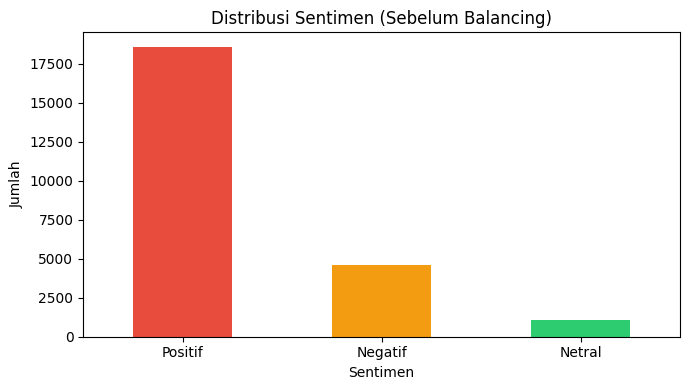

In [8]:
df['sentiment'].value_counts().plot(kind='bar', color=['#e74c3c','#f39c12','#2ecc71'], figsize=(7,4))
plt.title('Distribusi Sentimen (Sebelum Balancing)')
plt.xlabel('Sentimen'); plt.ylabel('Jumlah'); plt.xticks(rotation=0)
plt.tight_layout(); plt.show()


In [10]:
def clean_text(text):
    text = str(text).lower()
    text = re.sub(r'http\S+', '', text)
    text = re.sub(r'[^a-zA-Z\s]', ' ', text)
    text = re.sub(r'\s+', ' ', text)
    return text.strip()

df['clean_text'] = df['content'].apply(clean_text)
df = df.drop_duplicates(subset=['clean_text'])
print(f'Shape setelah clean: {df.shape}')


Shape setelah clean: (17454, 6)


labeling

In [33]:
label_map = {'Negatif': 0, 'Netral': 1, 'Positif': 2}
df['label'] = df['sentiment'].map(label_map)
print(df[['clean_text', 'sentiment', 'label']].head(5))


                                          clean_text sentiment  label
0                                       sangat bagus   Positif      2
1  keluar masuk keluar masuk sendiri mulu jaringa...   Positif      2
2  mohon maaf kenapa setiap kali ingin melihat ha...   Negatif      0
3                                              ulala   Positif      2
4                                             mantul   Positif      2


Distribusi setelah balancing:
sentiment
Positif    8922
Netral     4461
Negatif    4461
Name: count, dtype: int64


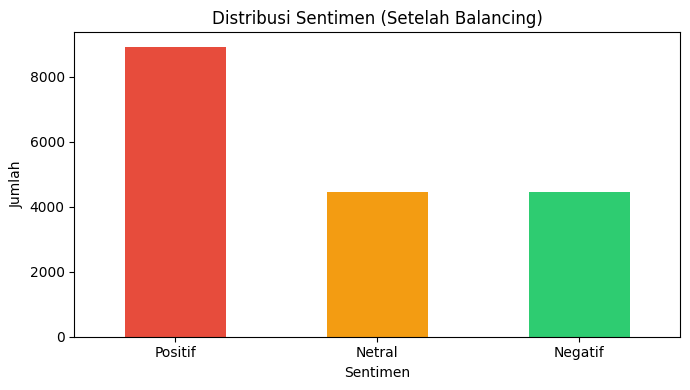

In [34]:
df_positif = df[df['sentiment'] == 'Positif']
df_negatif = df[df['sentiment'] == 'Negatif']
df_netral  = df[df['sentiment'] == 'Netral']

TARGET = len(df_negatif)  # jadikan Negatif sebagai target reference

# Oversample Netral supaya setara Negatif
df_netral_up = resample(df_netral, replace=True, n_samples=TARGET, random_state=42)

# Undersample Positif agar tidak terlalu dominan (maks 2x Negatif)
df_positif_down = resample(df_positif, replace=False, n_samples=min(len(df_positif), TARGET*2), random_state=42)

df_balanced = pd.concat([df_positif_down, df_negatif, df_netral_up])
df_balanced = df_balanced.sample(frac=1, random_state=42).reset_index(drop=True)

print('Distribusi setelah balancing:')
print(df_balanced['sentiment'].value_counts())

df_balanced['sentiment'].value_counts().plot(kind='bar', color=['#e74c3c','#f39c12','#2ecc71'], figsize=(7,4))
plt.title('Distribusi Sentimen (Setelah Balancing)')
plt.xlabel('Sentimen'); plt.ylabel('Jumlah'); plt.xticks(rotation=0)
plt.tight_layout(); plt.show()


In [35]:
class_weights = compute_class_weight(
    class_weight='balanced',
    classes=np.array([0, 1, 2]),
    y=df_balanced['label'].values
)
class_weights_tensor = torch.tensor(class_weights, dtype=torch.float).to(DEVICE)
print(f'Class weights:')
print(f'  Negatif : {class_weights[0]:.4f}')
print(f'  Netral  : {class_weights[1]:.4f}')
print(f'  Positif : {class_weights[2]:.4f}')


Class weights:
  Negatif : 1.3333
  Netral  : 1.3333
  Positif : 0.6667


## Bagian 3: Konfigurasi & Split Data


In [36]:
CONFIG = {
    'model_name'   : 'indobenchmark/indobert-base-p1',
    'max_length'   : 64,
    'batch_size'   : 32,
    'epochs'       : 5,
    'learning_rate': 2e-5,
    'test_size'    : 0.20,
    'random_state' : 42,
    'num_labels'   : 3,
    'text_col'     : 'clean_text',
    'label_col'    : 'label',
}

X = df_balanced[CONFIG['text_col']].values
y = df_balanced[CONFIG['label_col']].values

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size    = CONFIG['test_size'],
    random_state = CONFIG['random_state'],
    stratify     = y
)

print(f'Data balanced : {len(df_balanced)}')
print(f'Train         : {len(X_train)} sampel')
print(f'Test          : {len(X_test)}  sampel')


Data balanced : 17844
Train         : 14275 sampel
Test          : 3569  sampel


## Bagian 4: Tokenizer & Dataset


In [37]:
tokenizer = AutoTokenizer.from_pretrained(CONFIG['model_name'])

class SentimentDataset(Dataset):
    def __init__(self, texts, labels, tokenizer, max_length):
        self.texts     = texts
        self.labels    = labels
        self.tokenizer = tokenizer
        self.max_len   = max_length

    def __len__(self):
        return len(self.texts)

    def __getitem__(self, idx):
        encoding = self.tokenizer(
            self.texts[idx],
            max_length     = self.max_len,
            padding        = 'max_length',
            truncation     = True,
            return_tensors = 'pt'
        )
        return {
            'input_ids'     : encoding['input_ids'].squeeze(),
            'attention_mask': encoding['attention_mask'].squeeze(),
            'labels'        : torch.tensor(self.labels[idx], dtype=torch.long)
        }

train_dataset = SentimentDataset(X_train, y_train, tokenizer, CONFIG['max_length'])
test_dataset  = SentimentDataset(X_test,  y_test,  tokenizer, CONFIG['max_length'])

train_loader = DataLoader(train_dataset, batch_size=CONFIG['batch_size'], shuffle=True, num_workers=2, pin_memory=True)
test_loader  = DataLoader(test_dataset,  batch_size=CONFIG['batch_size'], shuffle=False)

print(f'Tokenizer   : {CONFIG["model_name"]}')
print(f'Train batch : {len(train_loader)}')
print(f'Test batch  : {len(test_loader)}')


config.json:   0%|          | 0.00/1.53k [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/2.00 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/229k [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

Tokenizer   : indobenchmark/indobert-base-p1
Train batch : 447
Test batch  : 112


## Bagian 5: Model & Training dengan Class Weight Loss

Loss function menggunakan `class_weights` agar model lebih memperhatikan kelas Netral.


In [38]:
model = AutoModelForSequenceClassification.from_pretrained(
    CONFIG['model_name'],
    num_labels=CONFIG['num_labels']
)
model.to(DEVICE)

# Loss dengan class weight
criterion = nn.CrossEntropyLoss(weight=class_weights_tensor)

optimizer    = AdamW(model.parameters(), lr=CONFIG['learning_rate'], weight_decay=0.01)
total_steps  = len(train_loader) * CONFIG['epochs']
warmup_steps = int(0.1 * total_steps)
scheduler    = get_linear_schedule_with_warmup(optimizer, warmup_steps, total_steps)

print(f'Model     : {CONFIG["model_name"]}')
print(f'Params    : {sum(p.numel() for p in model.parameters()):,}')
print(f'Loss fn   : CrossEntropyLoss (weighted)')
print(f'Steps     : {total_steps} total, {warmup_steps} warmup')


[transformers] You passed `num_labels=3` which is incompatible to the `id2label` map of length `5`.


pytorch_model.bin:   0%|          | 0.00/498M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

[transformers] BertForSequenceClassification LOAD REPORT from: indobenchmark/indobert-base-p1
Key               | Status  | 
------------------+---------+-
classifier.bias   | MISSING | 
classifier.weight | MISSING | 

Notes:
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Model     : indobenchmark/indobert-base-p1
Params    : 124,443,651
Loss fn   : CrossEntropyLoss (weighted)
Steps     : 2235 total, 223 warmup


In [39]:
def evaluate(model, loader):
    model.eval()
    all_preds, all_labels = [], []
    total_loss = 0

    with torch.no_grad():
        for batch in loader:
            input_ids      = batch['input_ids'].to(DEVICE)
            attention_mask = batch['attention_mask'].to(DEVICE)
            labels         = batch['labels'].to(DEVICE)

            outputs = model(input_ids=input_ids, attention_mask=attention_mask)
            loss    = criterion(outputs.logits, labels)
            total_loss += loss.item()

            preds = torch.argmax(outputs.logits, dim=1)
            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())

    avg_loss = total_loss / len(loader)
    acc      = accuracy_score(all_labels, all_preds)
    f1       = f1_score(all_labels, all_preds, average='weighted')
    return avg_loss, acc, f1, all_preds, all_labels

print('Fungsi evaluate() siap!')


Fungsi evaluate() siap!


In [40]:
history    = {'train_loss': [], 'val_loss': [], 'val_acc': [], 'val_f1': []}
best_f1    = 0
best_epoch = 0

for epoch in range(1, CONFIG['epochs'] + 1):
    model.train()
    total_train_loss = 0

    for step, batch in enumerate(train_loader):
        input_ids      = batch['input_ids'].to(DEVICE)
        attention_mask = batch['attention_mask'].to(DEVICE)
        labels         = batch['labels'].to(DEVICE)

        optimizer.zero_grad()
        outputs = model(input_ids=input_ids, attention_mask=attention_mask)
        loss    = criterion(outputs.logits, labels)
        total_train_loss += loss.item()

        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
        optimizer.step()
        scheduler.step()

        if (step + 1) % 50 == 0:
            print(f'  Epoch {epoch} | Step {step+1}/{len(train_loader)} | Loss: {loss.item():.4f}')

    avg_train_loss = total_train_loss / len(train_loader)
    val_loss, val_acc, val_f1, _, _ = evaluate(model, test_loader)

    history['train_loss'].append(avg_train_loss)
    history['val_loss'].append(val_loss)
    history['val_acc'].append(val_acc)
    history['val_f1'].append(val_f1)

    print(f'\nEpoch {epoch}/{CONFIG["epochs"]}')
    print(f'  Train Loss : {avg_train_loss:.4f}')
    print(f'  Val Loss   : {val_loss:.4f}')
    print(f'  Val Acc    : {val_acc:.4f}')
    print(f'  Val F1     : {val_f1:.4f}')

    if val_f1 > best_f1:
        best_f1    = val_f1
        best_epoch = epoch
        model.save_pretrained('best_indobert_model')
        tokenizer.save_pretrained('best_indobert_model')
        print(f'  Model terbaik disimpan! (F1: {best_f1:.4f})')
    print('-' * 55)

print(f'Best Model -> Epoch {best_epoch} | F1: {best_f1:.4f}')


  Epoch 1 | Step 50/447 | Loss: 0.9668
  Epoch 1 | Step 100/447 | Loss: 0.7310
  Epoch 1 | Step 150/447 | Loss: 0.8891
  Epoch 1 | Step 200/447 | Loss: 0.7446
  Epoch 1 | Step 250/447 | Loss: 0.6804
  Epoch 1 | Step 300/447 | Loss: 0.5522
  Epoch 1 | Step 350/447 | Loss: 0.5318
  Epoch 1 | Step 400/447 | Loss: 0.2662

Epoch 1/5
  Train Loss : 0.7140
  Val Loss   : 0.5361
  Val Acc    : 0.8083
  Val F1     : 0.8127


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

  Model terbaik disimpan! (F1: 0.8127)
-------------------------------------------------------
  Epoch 2 | Step 50/447 | Loss: 0.4103
  Epoch 2 | Step 100/447 | Loss: 0.5913
  Epoch 2 | Step 150/447 | Loss: 0.2950
  Epoch 2 | Step 200/447 | Loss: 0.2168
  Epoch 2 | Step 250/447 | Loss: 0.5133
  Epoch 2 | Step 300/447 | Loss: 0.8244
  Epoch 2 | Step 350/447 | Loss: 0.3377
  Epoch 2 | Step 400/447 | Loss: 0.3401

Epoch 2/5
  Train Loss : 0.3828
  Val Loss   : 0.3628
  Val Acc    : 0.8635
  Val F1     : 0.8658


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

  Model terbaik disimpan! (F1: 0.8658)
-------------------------------------------------------
  Epoch 3 | Step 50/447 | Loss: 0.2004
  Epoch 3 | Step 100/447 | Loss: 0.1586
  Epoch 3 | Step 150/447 | Loss: 0.1944
  Epoch 3 | Step 200/447 | Loss: 0.2815
  Epoch 3 | Step 250/447 | Loss: 0.0855
  Epoch 3 | Step 300/447 | Loss: 0.0525
  Epoch 3 | Step 350/447 | Loss: 0.0669
  Epoch 3 | Step 400/447 | Loss: 0.0987

Epoch 3/5
  Train Loss : 0.1940
  Val Loss   : 0.3937
  Val Acc    : 0.8876
  Val F1     : 0.8872


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

  Model terbaik disimpan! (F1: 0.8872)
-------------------------------------------------------
  Epoch 4 | Step 50/447 | Loss: 0.0105
  Epoch 4 | Step 100/447 | Loss: 0.0857
  Epoch 4 | Step 150/447 | Loss: 0.0195
  Epoch 4 | Step 200/447 | Loss: 0.0482
  Epoch 4 | Step 250/447 | Loss: 0.1236
  Epoch 4 | Step 300/447 | Loss: 0.1512
  Epoch 4 | Step 350/447 | Loss: 0.0676
  Epoch 4 | Step 400/447 | Loss: 0.0748

Epoch 4/5
  Train Loss : 0.1062
  Val Loss   : 0.4619
  Val Acc    : 0.8820
  Val F1     : 0.8820
-------------------------------------------------------
  Epoch 5 | Step 50/447 | Loss: 0.3051
  Epoch 5 | Step 100/447 | Loss: 0.0251
  Epoch 5 | Step 150/447 | Loss: 0.0877
  Epoch 5 | Step 200/447 | Loss: 0.0187
  Epoch 5 | Step 250/447 | Loss: 0.0083
  Epoch 5 | Step 300/447 | Loss: 0.0052
  Epoch 5 | Step 350/447 | Loss: 0.0204
  Epoch 5 | Step 400/447 | Loss: 0.0089

Epoch 5/5
  Train Loss : 0.0632
  Val Loss   : 0.5199
  Val Acc    : 0.8820
  Val F1     : 0.8809
-------------

## Bagian 6: Evaluasi Lengkap


In [41]:
best_model = AutoModelForSequenceClassification.from_pretrained('best_indobert_model')
best_model.to(DEVICE)

_, test_acc, test_f1, y_pred, y_true = evaluate(best_model, test_loader)
label_names = ['Negatif', 'Netral', 'Positif']

print(f'Accuracy : {test_acc:.4f} ({test_acc*100:.2f}%)')
print(f'F1 Score : {test_f1:.4f}')
print()
print('Classification Report:')
print(classification_report(y_true, y_pred, target_names=label_names))


Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

Accuracy : 0.8876 (88.76%)
F1 Score : 0.8872

Classification Report:
              precision    recall  f1-score   support

     Negatif       0.85      0.80      0.82       892
      Netral       0.85      0.95      0.90       892
     Positif       0.93      0.90      0.91      1785

    accuracy                           0.89      3569
   macro avg       0.88      0.88      0.88      3569
weighted avg       0.89      0.89      0.89      3569



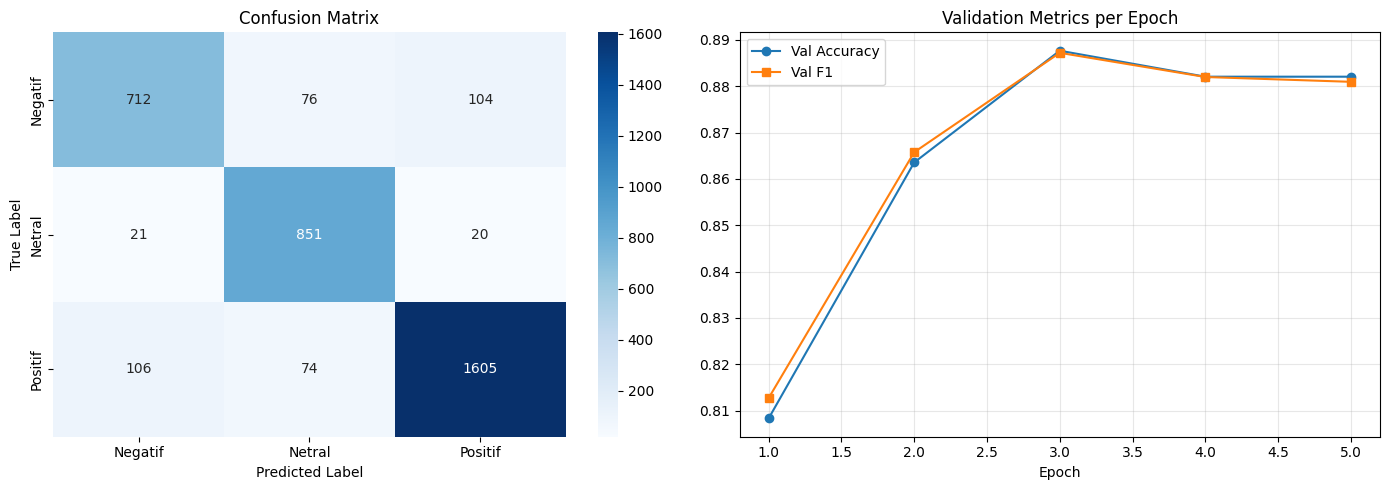

In [42]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Confusion Matrix
cm = confusion_matrix(y_true, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=label_names, yticklabels=label_names, ax=axes[0])
axes[0].set_title('Confusion Matrix')
axes[0].set_ylabel('True Label')
axes[0].set_xlabel('Predicted Label')

# Training History
epochs_range = range(1, len(history['val_acc'])+1)
axes[1].plot(epochs_range, history['val_acc'], label='Val Accuracy', marker='o')
axes[1].plot(epochs_range, history['val_f1'],  label='Val F1',       marker='s')
axes[1].set_title('Validation Metrics per Epoch')
axes[1].set_xlabel('Epoch')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()


## Bagian 6: Deploy ke hugging face

In [ ]:
from huggingface_hub import login, HfApi

HF_USERNAME = 'Raflixia'
HF_TOKEN    = 'Raflixiasecret'


REPO_NAME = f'{HF_USERNAME}/Review_Aplikasi_Shopee_di_Playstore'

login(token=HF_TOKEN)
print(f'Login berhasil!')
print(f'Repository: https://huggingface.co/{REPO_NAME}')


Login berhasil!
Repository: https://huggingface.co/Raflixia/Review_Aplikasi_Shopee_di_Playstore


In [47]:
# Tambahkan label mapping ke config model
best_model.config.id2label     = {0: 'Negatif', 1: 'Netral', 2: 'Positif'}
best_model.config.label2id     = {'Negatif': 0, 'Netral': 1, 'Positif': 2}
best_model.config.problem_type = 'single_label_classification'

print('Mengupload model ke HuggingFace Hub...')
best_model.push_to_hub(REPO_NAME, token=HF_TOKEN)
tokenizer.push_to_hub(REPO_NAME,  token=HF_TOKEN)

print(f'Model berhasil di-deploy!')
print(f'Link: https://huggingface.co/{REPO_NAME}')


Mengupload model ke HuggingFace Hub...


README.md:   0%|          | 0.00/5.17k [00:00<?, ?B/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Processing Files (0 / 0)      : |          |  0.00B /  0.00B            

New Data Upload               : |          |  0.00B /  0.00B            

  ...3f5hiq3/model.safetensors:   0%|          |  552kB /  498MB            

No files have been modified since last commit. Skipping to prevent empty commit.


Model berhasil di-deploy!
Link: https://huggingface.co/Raflixia/Review_Aplikasi_Shopee_di_Playstore


In [49]:
from huggingface_hub import HfApi
try:
    api = HfApi()
    user_info = api.whoami()
    print(f"Sukses terhubung sebagai: {user_info['name']}")
except Exception as e:
    print("Belum terhubung atau token tidak valid.")

Sukses terhubung sebagai: Raflixia
